### Importing Libraries

In [2]:
import pandas as pd
import numpy as np

### Prepping data for Models

Short Dataset Summary: <br>
 This archive contains a dataset of high-spatial resolution (1/24°, ~4-km) monthly climate and climatic water balance for global terrestrial surfaces from 1958-2015. These data were created by using climatically aided interpolation, combining high-spatial resolution climatological normals from the WorldClim version 1.4 and version 2 datasets, with coarser resolution time varying (i.e. monthly) data from CRU Ts4.0 and JRA-55 to produce a monthly dataset of precipitation, maximum and minimum temperature, wind speed, vapor pressure, and solar radiation. TerraClimate additionally produces monthly surface water balance datasets using a water balance model that incorporates reference evapotranspiration, precipitation, temperature, and interpolated plant extractable soil water capacity.


In [3]:
#import the Training_Data_allVar file as combined_df for all future operations
df1 = pd.read_csv("../data/Training_Data_allVar.csv")

In [4]:
df1.head()

,Latitude,Longitude,Occurrence Status,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
0,-34.027900,150.771000,1,200.799149,1.233,53.500000,65.300003,-4.5,115.500000,49.7,2.5,16.700001,0.0,23.900000,12.599999,0.81,3.6
1,-34.821595,147.193697,1,218.403992,0.942,24.700001,110.900002,-3.9,144.699997,25.9,1.3,2.500000,0.0,24.500000,10.900000,1.33,3.1
2,-36.617759,146.882941,0,204.000031,0.942,51.299999,28.200001,-3.8,115.099998,69.9,3.5,68.800003,0.0,21.400000,8.099999,0.78,3.2
3,-37.470900,144.744000,1,204.400146,0.951,41.000000,67.300003,-4.7,120.700005,45.0,2.3,11.300000,0.0,20.199999,8.000000,0.70,4.4
4,-38.400153,145.018560,1,189.203964,1.096,58.900002,29.500000,-4.8,109.500000,71.1,3.6,43.000000,0.0,18.900000,9.900000,0.50,5.6


In [5]:
# Now remove duplicates
columns_to_check = ['ppt','tmax','tmin','ws','srad','vap', 'Occurrence Status']
df2 = df1.drop_duplicates(subset=columns_to_check, keep='first')
df2.shape

(5285, 17)

In [6]:
# Resetting the index of the dataset
df2=df2.reset_index(drop=True)

In [8]:
df2.head()

,Latitude,Longitude,Occurrence Status,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
0,-34.027900,150.771000,1,200.799149,1.233,53.500000,65.300003,-4.5,115.500000,49.7,2.5,16.700001,0.0,23.900000,12.599999,0.81,3.6
1,-34.821595,147.193697,1,218.403992,0.942,24.700001,110.900002,-3.9,144.699997,25.9,1.3,2.500000,0.0,24.500000,10.900000,1.33,3.1
2,-36.617759,146.882941,0,204.000031,0.942,51.299999,28.200001,-3.8,115.099998,69.9,3.5,68.800003,0.0,21.400000,8.099999,0.78,3.2
3,-37.470900,144.744000,1,204.400146,0.951,41.000000,67.300003,-4.7,120.700005,45.0,2.3,11.300000,0.0,20.199999,8.000000,0.70,4.4
4,-38.400153,145.018560,1,189.203964,1.096,58.900002,29.500000,-4.8,109.500000,71.1,3.6,43.000000,0.0,18.900000,9.900000,0.50,5.6


In [ ]:
#Since I will be using standard scaler, it will normalize the data and handle the Outliers, so 
#no need to drop them

from scipy import stats
df_no_outliers = df2[(np.abs(stats.zscore(df2[['srad', 'tmax', 'tmin', 'vap', 'ws']])) < 3).all(axis=1)]
print("Rows before removing outliers:", len(df2))
print(f"Rows after removing outliers: {len(df_no_outliers)}")

Rows before removing outliers: 5285
Rows after removing outliers: 5140


In [8]:
df_no_outliers =df_no_outliers.reset_index(drop=True)

In [74]:
final_data = df_no_outliers[['srad','vap','ppt','tmax','tmin', 'ws', 'Occurrence Status']]

In [9]:
#Training Data
#use this block if not dropping outliers
final_data = df2[['srad','vap','ppt','tmax','tmin', 'ws', 'Occurrence Status']]

Prepping Validation Data

In [9]:
#Extracts satellite variables from a GeoTIFF based on coordinates from a CSV file and returns them in a DataFrame.

import pandas as pd
import numpy as np
import xarray as xr
import rasterio
from tqdm import tqdm

def map_satellite_data(tiff_path, csv_path):
    df = pd.read_csv(csv_path)

    # Open the GeoTIFF file and load data into xarray DataArrays
    with rasterio.open(tiff_path) as dataset:
        # Read all 14 bands into a dictionary
        variable_names = ["srad", "vap", "aet", "def", "pdsi", "pet", "ppt", "q", "soil",  
                          "swe", "tmax", "tmin", "vpd", "ws"]
        
        # Read all bands and store them in a dictionary of DataArrays
        data_arrays = {}
        for i, var_name in enumerate(variable_names, start=1):
            data = dataset.read(i)  # Read the i-th band
            lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
            lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)
            
            # Create an xarray DataArray for each variable
            data_arrays[var_name] = xr.DataArray(data, coords=[("lat", lat), ("lon", lon)], dims=["lat", "lon"])

    # Initialize lists to store extracted values for each variable
    extracted_values = {var: [] for var in variable_names}

    # Extract values for each row in the DataFrame
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Extracting raster values"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]

        for var_name in variable_names:
            try:
                # Extract the nearest value from the DataArray
                value = data_arrays[var_name].sel(lat=target_lat, lon=target_lon, method="nearest").values
            except KeyError:
                # Handle cases where coordinates are outside raster bounds
                value = np.nan

            extracted_values[var_name].append(value)

    # Create a DataFrame to store all extracted values
    df_result = pd.DataFrame(extracted_values)

    return df_result

In [52]:
#Reading the coordinates for the validation dataset
test_file = pd.read_csv('../data/Validation_Template.csv')
test_file.head()

,Latitude,Longitude
0,-33.121788,150.320746
1,-36.592011,148.172262
2,-35.455100,146.693465
3,-33.076261,149.547177
4,-35.529729,146.627272


In [11]:
test_file.shape

(2000, 2)

In [12]:
# Mapping satellite data with test data.
final_val_data = map_satellite_data('../data/TerraClimate_output_allVar.tiff', '../data/Validation_Template.csv')

Extracting raster values: 100%|██████████| 2000/2000 [00:07<00:00, 271.81it/s]


In [13]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [14]:
# Combining ground data and final data into a single dataset.
combined_validation_data = combine_two_datasets(test_file, final_val_data)
combined_validation_data.head()

,Latitude,Longitude,srad,vap,aet,def,pdsi,pet,ppt,q,soil,swe,tmax,tmin,vpd,ws
0,-33.121788,150.320746,205.69839477539062,1.0170000791549683,39.10000228881836,51.900001525878906,-4.599999904632568,105.80000305175781,40.1,2.0,11.300000190734863,0.0,21.5,9.199999809265137,0.7400000095367432,2.8999998569488525
1,-36.592011,148.172262,197.801513671875,0.8270000219345093,48.79999923706055,23.5,-4.799999713897705,108.20000457763672,62.6,3.1,29.30000114440918,0.0,18.5,5.0,0.5299999713897705,3.6999998092651367
2,-35.455100,146.693465,221.59686279296875,0.9630000591278076,24.399999618530273,115.0,-4.400000095367432,139.60000610351562,24.900000000000002,1.2000000000000002,2.799999952316284,0.0,24.299999237060547,10.699999809265137,1.159999966621399,3.1999998092651367
3,-33.076261,149.547177,219.70147705078125,0.9620000720024109,37.79999923706055,63.5,-4.299999713897705,118.0999984741211,39.5,2.0,4.900000095367432,0.0,21.299999237060547,8.0,0.8499999642372131,3.3999998569488525
4,-35.529729,146.627272,221.70089721679688,0.9640000462532043,24.700000762939453,113.5,-4.400000095367432,138.10000610351562,25.5,1.3,2.9000000953674316,0.0,24.100000381469727,10.399999618530273,1.159999966621399,3.1999998092651367


In [15]:
columns_to_check = ['srad', 'vap', 'aet',
       'def', 'pdsi', 'pet', 'ppt', 'q', 'soil', 'swe', 'tmax', 'tmin', 'vpd',
       'ws']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    combined_validation_data[col] = combined_validation_data[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.ndim == 0 else x)

In [16]:
combined_validation_data.dtypes

Latitude     float64
Longitude    float64
srad         float64
vap          float64
aet          float64
def          float64
pdsi         float64
pet          float64
ppt          float64
q            float64
soil         float64
swe          float64
tmax         float64
tmin         float64
vpd          float64
ws           float64
dtype: object

In [ ]:
#Uncomment if running the above code for the first time
#combined_validation_data.to_csv('../data/Validation_Data_allVar.csv', index = False)

In [10]:
combined_validation_data = pd.read_csv('../data/Validation_Data_allVar.csv')

### Model 1: Random Forest and Tuned Random Forest

In [11]:
final_data.describe()

,srad,vap,ppt,tmax,tmin,ws,Occurrence Status
count,5285.000000,5285.000000,5285.000000,5285.000000,5285.000000,5285.000000,5285.000000
mean,206.579565,1.001957,45.797824,21.822384,9.201741,3.854488,0.532640
std,12.600953,0.124070,18.904902,2.788198,2.210589,0.781725,0.498981
min,177.800842,0.564000,10.100000,10.000000,0.900000,2.600000,0.000000
25%,197.198166,0.938000,32.100000,19.799999,7.700000,3.200000,0.000000
50%,205.000305,0.978000,43.300000,21.299999,9.099999,3.600000,1.000000
75%,216.299408,1.050000,57.100000,23.900000,10.700000,4.300000,1.000000
max,236.496948,1.468000,127.800000,28.199999,14.799999,7.050000,1.000000


In [12]:
final_data.head()

,srad,vap,ppt,tmax,tmin,ws,Occurrence Status
0,200.799149,1.233,49.7,23.900000,12.599999,3.6,1
1,218.403992,0.942,25.9,24.500000,10.900000,3.1,1
2,204.000031,0.942,69.9,21.400000,8.099999,3.2,0
3,204.400146,0.951,45.0,20.199999,8.000000,4.4,1
4,189.203964,1.096,71.1,18.900000,9.900000,5.6,1


In [13]:
# Define features and target.
X = final_data.iloc[:,0:-1]
y = final_data['Occurrence Status'].values

In [14]:
from sklearn.model_selection import train_test_split

# Assuming your data is in a NumPy array or Pandas DataFrame called 'data'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
#No need to scale the features for Random Forest

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
#Random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Initialize and train a baseline Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Baseline model with 100 trees
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f"F1 Score: {f1:.4f}")
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 0.6802
F1 Score: 0.6949
Confusion Matrix:
 [[334 160]
 [178 385]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.68      0.66       494
           1       0.71      0.68      0.69       563

    accuracy                           0.68      1057
   macro avg       0.68      0.68      0.68      1057
weighted avg       0.68      0.68      0.68      1057



In [30]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],          # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],         # Maximum depth of trees
    'min_samples_split': [2, 5, 10],         # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],           # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2']         # Number of features to consider at each split
}

# Initialize RandomForest classifier
rf_model = RandomForestClassifier(random_state=42)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='accuracy',        # Optimize for accuracy
    n_jobs=-1,                 # Use all available CPU cores
    verbose=2                  # Show progress
)

# Fit GridSearchCV on training data
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

In [31]:
# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.7169


In [32]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

In [33]:
# Evaluate on the test set
y_pred = best_rf_model.predict(X_test)
f1 = f1_score(y_test, y_pred)

# Print test accuracy and classification report
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.7294
F1 Score: 0.7496
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.71       494
           1       0.74      0.76      0.75       563

    accuracy                           0.73      1057
   macro avg       0.73      0.73      0.73      1057
weighted avg       0.73      0.73      0.73      1057



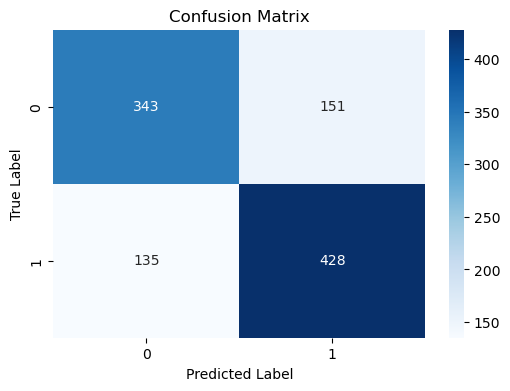

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


Making prediction on the validation dataset using the model

In [145]:
val_data = combined_validation_data[['srad','vap','ppt','tmax','tmin', 'ws']]

In [146]:
# Make predictions using the tuned model
final_predictions = best_rf_model.predict(val_data)
final_prediction_series = pd.Series(final_predictions)

In [147]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Latitude':test_file['Latitude'].values, 'Longitude':test_file['Longitude'].values,  'Occurrence Status':final_prediction_series.values})


In [150]:
#Dumping the predictions into a csv file.
submission_df.to_csv("../submission_validation_files/Predicted_Data_RF_tuned.csv",index = False)

### Model 2: SVM

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report


# Initialize and train the SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [135]:
# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7124
F1 Score: 0.7471

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.62      0.67       494
           1       0.70      0.80      0.75       563

    accuracy                           0.71      1057
   macro avg       0.71      0.71      0.71      1057
weighted avg       0.71      0.71      0.71      1057



Making prediction on validation Dataset using baseline SVM

In [ ]:
val_data_scaled = scaler.transform(val_data)

In [152]:
# Make predictions using the tuned model
final_predictions = svm_model.predict(val_data_scaled)
final_prediction_series = pd.Series(final_predictions)

In [153]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Latitude':test_file['Latitude'].values, 'Longitude':test_file['Longitude'].values,  'Occurrence Status':final_prediction_series.values})

In [154]:
#Dumping the predictions into a csv file.
submission_df.to_csv("../submission_validation_files/Predicted_Data_SVM.csv",index = False)

SVM Tuned

In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 0.5, 1, 10, 100],          # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernel types
    'gamma': ['scale', 'auto']         # Kernel coefficient
}

# Initialize the SVM classifier
svm_model = SVC()

In [17]:
# Perform Grid Search with Cross Validation
grid_search_svm = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_svm.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 0.5, 1, 10, 100],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

In [19]:
# Get the best SVM model
best_svm_model = grid_search_svm.best_estimator_

In [ ]:
# Make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test_scaled)

# Evaluate performance
print("Best Parameters:", grid_search_svm.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nF1-Score:", f1_score(y_test, y_pred_svm))

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72       494
           1       0.75      0.79      0.77       563

    accuracy                           0.75      1057
   macro avg       0.75      0.74      0.74      1057
weighted avg       0.75      0.75      0.75      1057


F1 Score: 0.7693631669535284


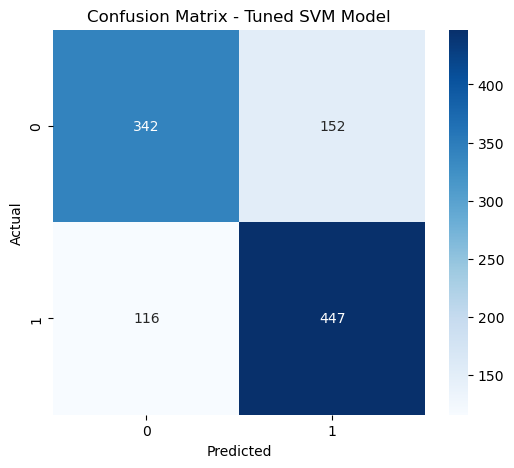

In [23]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM Model")
plt.show()

Creating the Predicted Data file using the validation Dataset

In [48]:
val_data = combined_validation_data[['srad','vap','ppt','tmax','tmin', 'ws']]

In [49]:
val_data_scaled = scaler.transform(val_data)

In [51]:
# Make predictions using the tuned model
final_predictions = best_svm_model.predict(val_data_scaled)
final_prediction_series = pd.Series(final_predictions)

In [53]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Latitude':test_file['Latitude'].values, 'Longitude':test_file['Longitude'].values,  'Occurrence Status':final_prediction_series.values})

In [54]:
#Dumping the predictions into a csv file.
submission_df.to_csv("../submission_validation_files/Predicted_Data_SVM_tuned.csv",index = False)

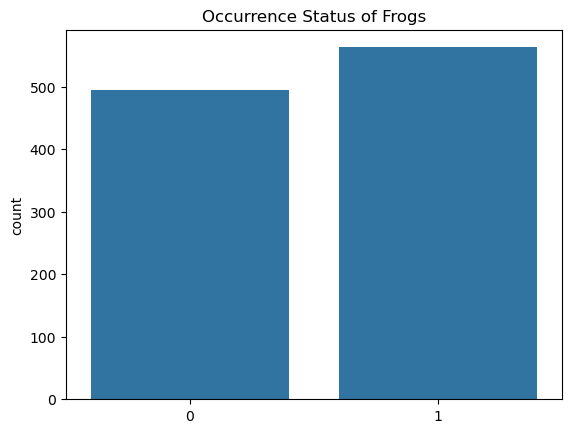

In [30]:
sns.countplot(x=y_test)
plt.title("Occurrence Status of Frogs")
plt.show()

XGBoost Model

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],          # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage
    'subsample': [0.7, 1.0],         # Fraction of samples used per tree
    'colsample_bytree': [0.7, 1.0]   # Fraction of features used per tree
}

# Perform Grid Search with Cross Validation
grid_search_xgb = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


c:\Users\faizh\anaconda3\envs\dev_env\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:00:59] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 1.0],
                         'learning_rate': [0.005, 0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 1.0]},
             scoring='accuracy', verbose=2)

In [46]:
# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

In [47]:
# Make predictions on the test set
y_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate performance
print("Best Parameters:", grid_search_xgb.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nF1 Score:", f1_score(y_test, y_pred_xgb))

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.64      0.68       494
           1       0.72      0.80      0.76       563

    accuracy                           0.72      1057
   macro avg       0.73      0.72      0.72      1057
weighted avg       0.73      0.72      0.72      1057


F1 Score: 0.7556675062972292


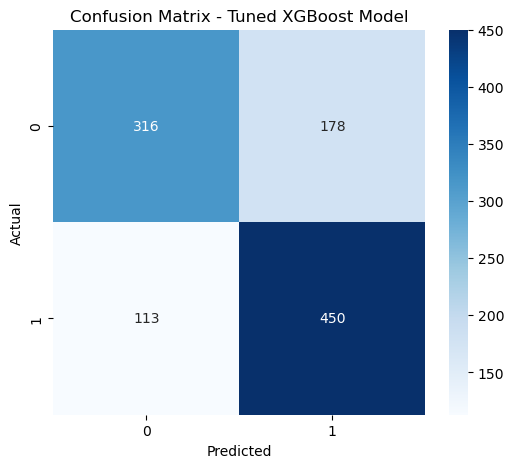

In [39]:
# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost Model")
plt.show()

Creating the Predicted Data file using the validation dataset

In [55]:
# Make predictions using the tuned model
final_predictions = best_xgb_model.predict(val_data)
final_prediction_series = pd.Series(final_predictions)

In [56]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Latitude':test_file['Latitude'].values, 'Longitude':test_file['Longitude'].values,  'Occurrence Status':final_prediction_series.values})

In [57]:
#Dumping the predictions into a csv file.
submission_df.to_csv("../submission_validation_files/Predicted_Data_XGBoost_tuned.csv",index = False)